# Experiment 4 : Spatial Signaling and Proliferation

**Drug Modeled:** Gefitinib

**Condition Tested:** EGFR signaling and proliferation rates in a drug gradient

**Research Question:** How do spatial drug gradients create biological response gradients?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters

# Tissue depth range (cm)
L = 0.2
nx = 200

x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Diffusion simulation time (s)
T_diffusion = 3600
nt = 30000

dt = T_diffusion / nt

# Layer boundaries (cm)
boundary_1 = 0.05
boundary_2 = 0.12

# Diffusion coefficients (cm^2/s)
D1 = 5e-7
D2 = 1e-7
D3 = 5e-7

# Spatial diffusivity profile
D = np.full(nx, D1)

D[x >= boundary_1] = D2
D[x >= boundary_2] = D3

# Constant drug source at vessel boundary
C_source = 1.0

# Initial concentration
C = np.zeros(nx)

C[0] = C_source

# Save concentration profiles over time
save_every = 25
saved_profiles = []

In [195]:
# Diffusion simulation
for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):
        D_left = (D[i] + D[i-1]) / 2
        D_right = (D[i] + D[i+1]) / 2

        J_left = -D_left * (C[i] - C[i-1]) / dx
        J_right = -D_right * (C[i+1] - C[i]) / dx

        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C = C_new

    # Constant source boundary
    C[0] = C_source

    if t % save_every == 0:
        saved_profiles.append(C.copy())

# Final spatial gefitinib concentration
G = C.copy()

# Saving gefitinib concentration profile for sensitivity analysis
np.save("exp04b_G.npy", G)

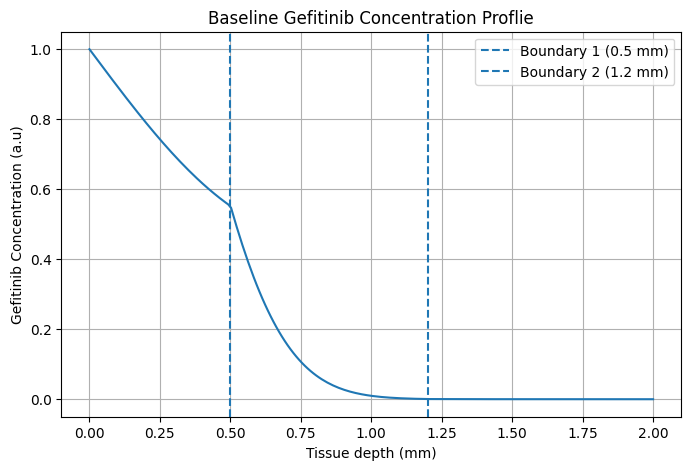

In [196]:
# Plot
plt.figure(figsize=(8, 5))

plt.plot(x * 10, G)

plt.title("Baseline Gefitinib Concentration Proflie")
plt.xlabel("Tissue depth (mm)")
plt.ylabel("Gefitinib Concentration (a.u)")

plt.axvline(boundary_1 * 10, linestyle="--", label="Boundary 1 (0.5 mm)")
plt.axvline(boundary_2 * 10, linestyle="--", label="Boundary 2 (1.2 mm)")

plt.savefig("figures/exp04b-A-baseline_gefit")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters

# Initial state vector
y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Parameter dictionary
params = {
    "EGF" : 1.0,
    "IC_50" : 0.3,
    "n" : 1.0,
    "k_EGF" : 1.0,
    "k_EGFR_off" : 0.5,
    "k_RAS" : 1.0,
    "k_RAS_off" : 0.5,
    "k_RAF" : 1.0,
    "k_RAF_off" : 0.5,
    "k_MEK" : 1.0,
    "k_MEK_off" : 0.5,
    "k_ERK" : 1.0,
    "k_ERK_off" : 0.5,
    "k_T" : 1.0,
    "k_deg" : 0.5,
    "k_P" : 1.0,
    "k_loss" : 0.5,
}

species = [
    "EGFR*",
    "RAS*",
    "RAF*",
    "MEK*",
    "ERK*",
    "Cyclin D",
    "P"
]

# Final solution array
solutions_final = np.zeros((7, nx))

# Steady-state run time
T_steady = 80
T_eval = np.linspace(0, T_steady, 500)

# Saving steady-state run time for sensitivity analysis
np.save("saved_parameters/exp04b_T_steady.npy", T_steady)

# ODE function definition
def pathway(t, y, params, G_x):
    # External factors
    EGF = params["EGF"]
    G = G_x
    IC_50 = params["IC_50"]
    n = params["n"]

    # Extract activated protein and Cyclin D/Proliferation rates from array y
    EGFR_star, RAS_star, RAF_star, MEK_star, ERK_star, CycD, P = y

    # Total protein concentrations
    EGFR_tot = 1.0
    RAS_tot = 1.0
    RAF_tot = 1.0
    MEK_tot = 1.0
    ERK_tot = 1.0

    # Rate constants (normalized currently)
    k_EGF = params["k_EGF"]
    k_EGFR_off = params["k_EGFR_off"]

    k_RAS = params["k_RAS"]
    k_RAS_off = params["k_RAS_off"]

    k_RAF = params["k_RAF"]
    k_RAF_off = params["k_RAF_off"]

    k_MEK = params["k_MEK"]
    k_MEK_off = params["k_MEK_off"]

    k_ERK = params["k_ERK"]
    k_ERK_off = params["k_ERK_off"]

    k_T = params["k_T"]
    k_deg = params["k_deg"]

    k_P = params["k_P"]
    k_loss = params["k_loss"]

    # Calculating derivatives
    EGFR_gefit = 1 / (1 + (G / IC_50) ** n)
    EGFR_act = k_EGF * EGF * (EGFR_tot - EGFR_star) * EGFR_gefit
    EGFR_dect = k_EGFR_off * EGFR_star

    dEGFR = EGFR_act - EGFR_dect

    RAS_act = k_RAS * EGFR_star * (RAS_tot - RAS_star)
    RAS_dect = k_RAS_off * RAS_star

    dRAS = RAS_act - RAS_dect

    RAF_act = k_RAF * RAS_star * (RAF_tot - RAF_star)
    RAF_dect = k_RAF_off * RAF_star

    dRAF = RAF_act - RAF_dect

    MEK_act = k_MEK * RAF_star * (MEK_tot - MEK_star)
    MEK_dect = k_MEK_off * MEK_star

    dMEK = MEK_act - MEK_dect

    ERK_act = k_ERK * MEK_star * (ERK_tot - ERK_star)
    ERK_dect = k_ERK_off * ERK_star

    dERK = ERK_act - ERK_dect

    CycD_act = k_T * ERK_star
    CycD_dect = k_deg * CycD

    dCycD = CycD_act - CycD_dect

    P_act = k_P * CycD
    P_dect = k_loss * P

    dP = P_act - P_dect

    return [dEGFR, dRAS, dRAF, 
                dMEK, dERK, dCycD, dP]

In [ ]:
for i in range(nx):

    G_local = G[i]

    solution = solve_ivp(
        pathway,
        [0, T_steady],
        y0,
        args=(params, G_local),
        t_eval=T_eval,
        rtol=1e-9,
        atol=1e-12
    )

    if not solution.success:
        print(f"Solver failed at x = {x[i]:.4f} cm")
        print(solution.message)
        continue

    solutions_final[:, i] = solution.y[:, -1]

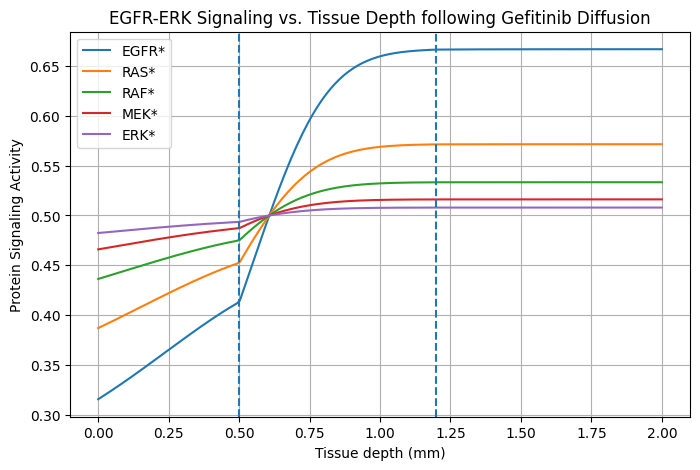

In [199]:
# Plot 1 (EGFR*)

plt.figure(figsize=(8, 5))

plt.plot(x * 10, solutions_final[0], label="EGFR*")
plt.plot(x * 10, solutions_final[1], label="RAS*")
plt.plot(x * 10, solutions_final[2], label="RAF*")
plt.plot(x * 10, solutions_final[3], label="MEK*")
plt.plot(x * 10, solutions_final[4], label="ERK*")

plt.xlabel("Tissue depth (mm)")
plt.ylabel("Protein Signaling Activity")

plt.title("EGFR-ERK Signaling vs. Tissue Depth following Gefitinib Diffusion")

plt.axvline(boundary_1 * 10, linestyle="--")
plt.axvline(boundary_2 * 10, linestyle="--")

plt.legend()
plt.grid()
plt.show()

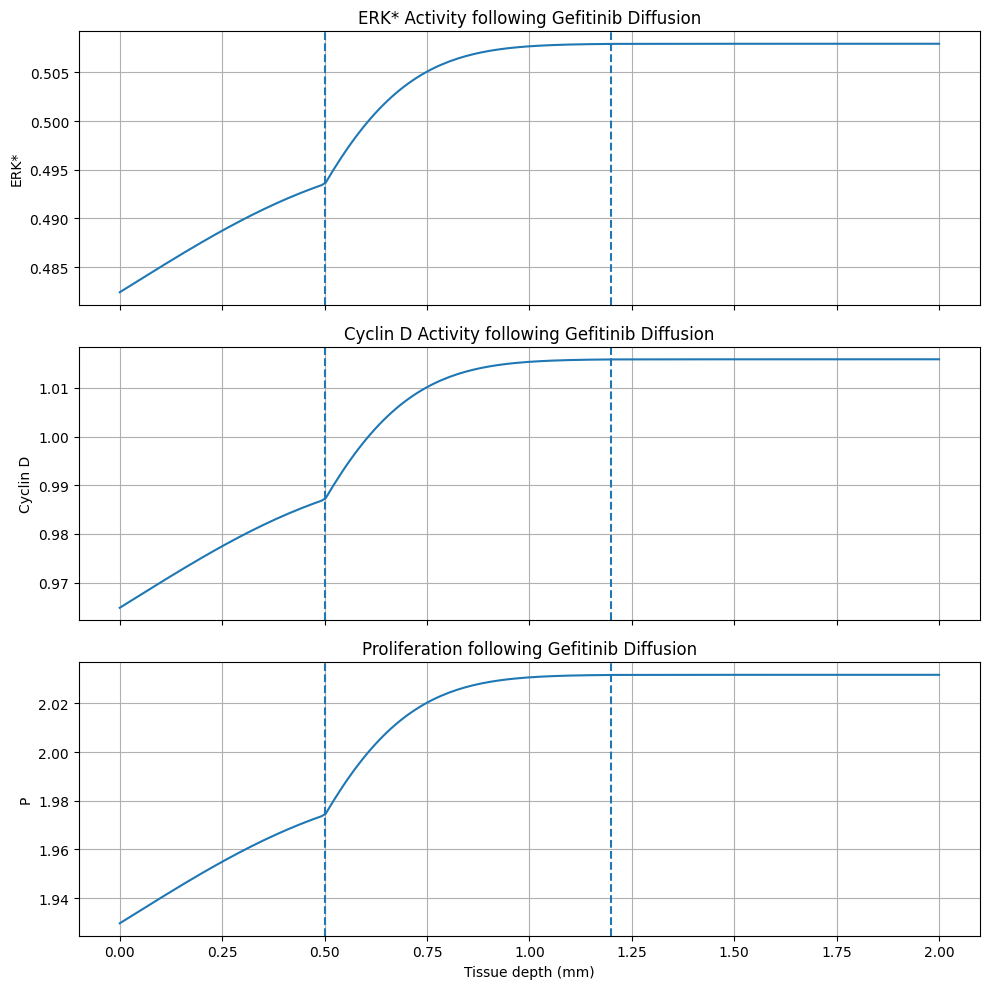

In [200]:
# Plot
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Panel 1
axes[0].plot(x * 10, solutions_final[4])
axes[0].set_ylabel("ERK*")
axes[0].set_title("ERK* Activity following Gefitinib Diffusion")
axes[0].grid(True)

# Panel 2
axes[1].plot(x * 10, solutions_final[5])
axes[1].set_ylabel("Cyclin D")
axes[1].set_title("Cyclin D Activity following Gefitinib Diffusion")
axes[1].grid(True)

# Panel 3
axes[2].plot(x * 10, solutions_final[6])
axes[2].set_ylabel("P")
axes[2].set_title("Proliferation following Gefitinib Diffusion")
axes[2].set_xlabel("Tissue depth (mm)")
axes[2].grid(True)

# Tissue boundaries
for ax in axes:
    ax.axvline(0.5, linestyle="--")
    ax.axvline(1.2, linestyle="--")

plt.tight_layout()
plt.show()

## Results/Anaylsis

In this section, each graph's results will be analyzed and validated.

In [201]:
# Results/Analysis

variables = {
    "G": G,
    "EGFR*": solutions_final[0],
    "RAS*": solutions_final[1],
    "RAF*": solutions_final[2],
    "MEK*": solutions_final[3],
    "ERK*": solutions_final[4],
    "CycD": solutions_final[5],
    "P": solutions_final[6]
}

for name, arr in variables.items():
    ymin = np.min(arr)
    ymax = np.max(arr)
    pct = (ymax - ymin) / ymin * 100

    print(
        f"{name:6s} | "
        f"min = {ymin:.6f} | "
        f"max = {ymax:.6f} | "
        f"change = {pct:.3f}%"
    )

diff_G = np.diff(G)

bad_indices = np.where(diff_G > 0)[0]

print("Number of increases:", len(bad_indices))
print("Largest increase:", np.max(diff_G) if len(bad_indices) > 0 else 0)

# Calculate relative spatial change for each component
spatial_changes = {}

for name, y in variables.items():
    ymin = np.min(y)
    ymax = np.max(y)

    if ymin == 0:
        spatial_changes[name] = np.inf
    else:
        spatial_changes[name] = (ymax - ymin) / ymin * 100

# Calculate attenuation between consecutive components
names = list(variables.keys())

for i in range(1, len(names)):
    previous = names[i - 1]
    current = names[i]

    prev_change = spatial_changes[previous]
    curr_change = spatial_changes[current]

    if np.isinf(prev_change):
        attenuation = np.nan
    else:
        attenuation = (1 - curr_change / prev_change) * 100

    print(
        f"{previous} -> {current}: "
        f"{attenuation:.3f}% attenuation"
    )

G      | min = 0.000000 | max = 1.000000 | change = inf%
EGFR*  | min = 0.315789 | max = 0.666667 | change = 111.111%
RAS*   | min = 0.387097 | max = 0.571429 | change = 47.619%
RAF*   | min = 0.436364 | max = 0.533333 | change = 22.222%
MEK*   | min = 0.466019 | max = 0.516129 | change = 10.753%
ERK*   | min = 0.482412 | max = 0.507937 | change = 5.291%
CycD   | min = 0.964824 | max = 1.015873 | change = 5.291%
P      | min = 1.929648 | max = 2.031746 | change = 5.291%
Number of increases: 0
Largest increase: 0
G -> EGFR*: nan% attenuation
EGFR* -> RAS*: 57.143% attenuation
RAS* -> RAF*: 53.333% attenuation
RAF* -> MEK*: 51.613% attenuation
MEK* -> ERK*: 50.794% attenuation
ERK* -> CycD: 0.000% attenuation
CycD -> P: -0.000% attenuation


/var/folders/sj/6mw6cz_x1dg1nlhv9xgk5rgh0000gn/T/ipykernel_12705/1458474758.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  pct = (ymax - ymin) / ymin * 100


Spatial heterogeneity was progressively attenuated through the EGFR–ERK signaling cascade. Relative spatial variation decreased by 57.1% from EGFR* to RAS*, 53.3% from RAS* to RAF*, 51.6% from RAF* to MEK*, and 50.8% from MEK* to ERK*, corresponding to a mean attenuation of approximately 53.2% per signaling step. The relative spatial variation was subsequently preserved in Cyclin D and proliferation.